In [1]:
!pip install tensorflow-datasets

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 3.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 1.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 2.9 MB/s  0:00:14m0:00:0100:01
  DEPRECATION: Building 'promise' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'promise'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21581 sha256=14f8897bbc4ad84e4ec6363292d0899872e1bec0e913ea2650f6e29cc5dc2416
  Stored in directory: /home/narra/.cache/pip/wheels/e7/e6/28/864bdfee5339dbd6ddcb5a186286a8e

In [1]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

2025-10-05 09:21:44.785450: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-05 09:21:45.863242: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-05 09:21:50.354448: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

gpu = tf.config.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(gpu[0], True)

2025-10-05 12:39:26.961979: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-05 12:39:27.696314: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-05 12:39:30.733584: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow_datasets as tfds
import numpy as np

#dataset, info = tfds.load('emnist/letters', with_info=True, as_supervised=True)  gives only letters A-Z
dataset, info = tfds.load('emnist/byclass', with_info=True, as_supervised=True)

train_ds, test_ds = dataset['train'], dataset['test']

print("Train size:", info.splits['train'].num_examples)
print("Test size:", info.splits['test'].num_examples)
print("Number of classes:", info.features['label'].num_classes)

/home/narra/mnt/c/Users/narra/gpu_env_tf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [01:51<00:00, 107.86s/ url]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1759656241.730491     834 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Dataset emnist downloaded and prepared to /home/narra/tensorflow_datasets/emnist/byclass/3.1.0. Subsequent calls will reuse this data.
Train size: 697932
Test size: 116323
Number of classes: 62


In [ ]:

train_np = tfds.as_numpy(train_ds)
X_train, y_train = zip(*list(train_np)[:])
X_train = np.array(X_train)
test_np = tfds.as_numpy(test_ds)
X_test, y_test = zip(*list(test_np)[:])
X_test = np.array(X_test)

2025-10-05 09:41:58.773894: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-10-05 09:43:31.203165: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
X_train.shape,X_test.shape

((697932, 28, 28, 1), (116323, 28, 28, 1))

In [26]:
# Fix EMNIST orientation and normalize
X_train_raw = X_train[:,:,:,0]  # Remove channel dimension
X_test_raw = X_test[:,:,:,0]   # Remove channel dimension


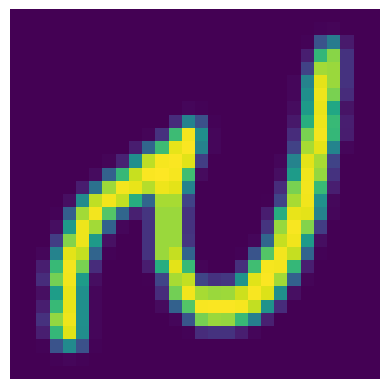

Label: 5


In [27]:
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.axis("off")
plt.show()
print(f"Label: {y_train[0]}")

In [28]:

# Correct EMNIST orientation: rotate 90° counterclockwise and flip horizontally
print("Correcting EMNIST image orientation...")
X_train = np.array([np.rot90(np.fliplr(img)) for img in X_train_raw]) / 255.0
X_test = np.array([np.rot90(np.fliplr(img)) for img in X_test_raw]) / 255.0

y_train = np.array(y_train)
y_test = np.array(y_test)

print("EMNIST orientation corrected and images normalized!")

Correcting EMNIST image orientation...
EMNIST orientation corrected and images normalized!
EMNIST orientation corrected and images normalized!


In [ ]:
import h5py
import numpy as np

# Open the file in write mode
with h5py.File('emnist_data.h5', 'w') as f:
    f.create_dataset('X_train', data=X_train)
    f.create_dataset('y_train', data=y_train)
    f.create_dataset('X_test', data=X_test)
    f.create_dataset('y_test', data=y_test)


In [ ]:
import pickle

with open('emnist.pkl', 'wb') as f:
    pickle.dump(((x_train, y_train), (x_test, y_test)), f)


In [5]:
X_train.shape

(697932, 28, 28)

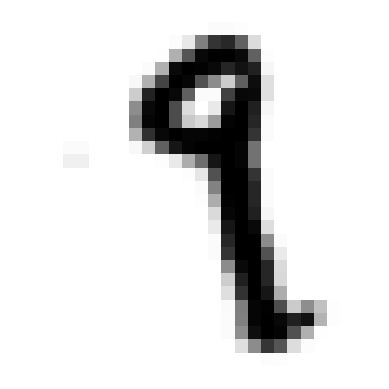

52


In [29]:
import matplotlib
digit=X_train[25]
digit_image=digit.reshape(28,28)
plt.imshow(digit_image,cmap=matplotlib.cm.binary,interpolation="nearest")
plt.axis("off")
plt.show()
print(y_train[25])

In [36]:
# Check unique labels in the dataset
np.unique(y_train), np.unique(y_test)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]))

## Data Analysis & Visualization

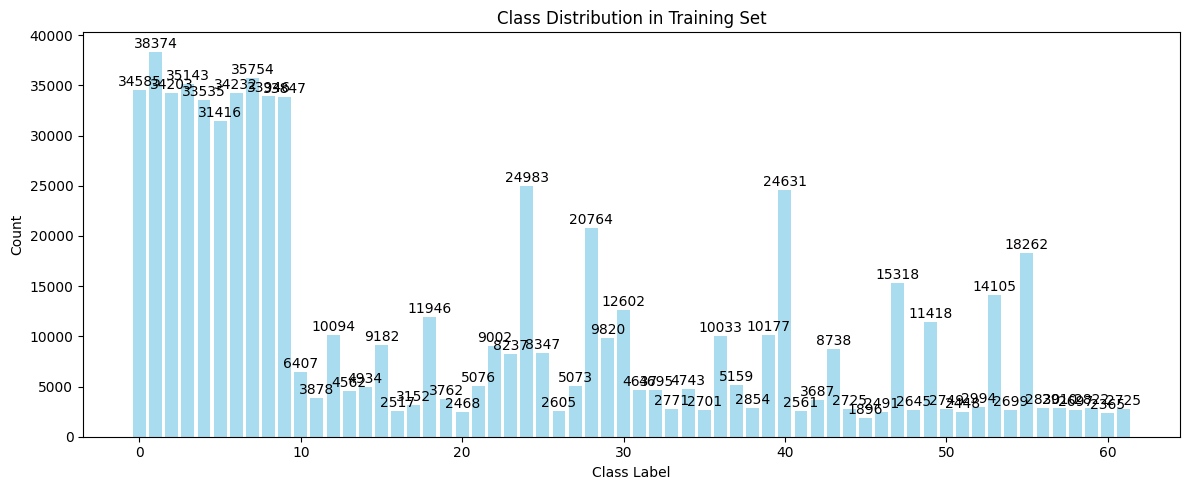

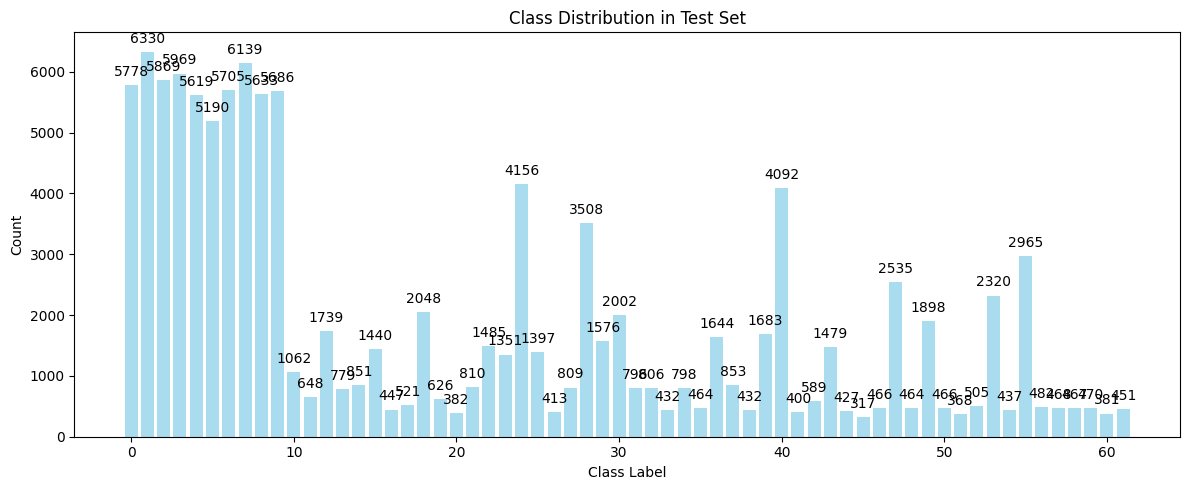

<Figure size 1200x600 with 0 Axes>

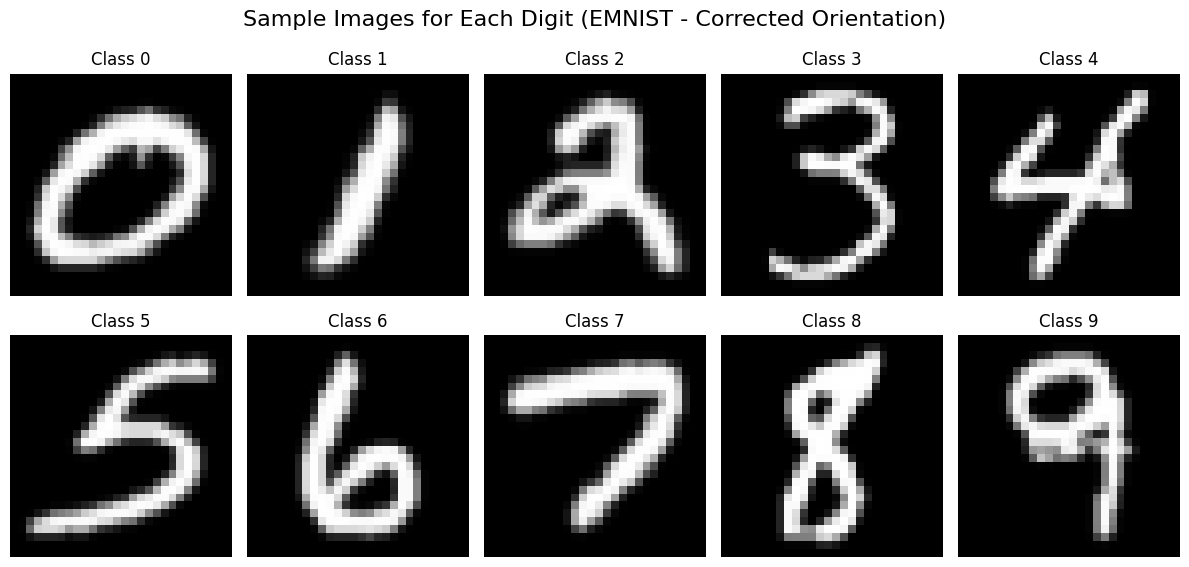

Dataset Statistics:
Training images: 697,932
Test images: 116,323
Image dimensions: 28x28
Pixel value range: 0.000 - 1.000
Pixel value range: 0.000 - 1.000
Mean pixel intensity: 0.174
Mean pixel intensity: 0.174
Standard deviation: 0.332
Standard deviation: 0.332


In [31]:
# Show class distribution
plt.figure(figsize=(12, 5))
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts, color='skyblue', alpha=0.7)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


# Show class distribution
plt.figure(figsize=(12, 5))
unique, counts = np.unique(y_test, return_counts=True)
plt.bar(unique, counts, color='skyblue', alpha=0.7)
plt.title('Class Distribution in Test Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


# Show sample images for each digit
plt.figure(figsize=(12, 6))
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
plt.suptitle('Sample Images for Each Digit (EMNIST - Corrected Orientation)', fontsize=16)

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y_train == digit)[0][0]
    row = digit // 5
    col = digit % 5
    # X_train is already corrected in preprocessing, so use directly
    axes[row, col].imshow(X_train[idx], cmap='gray')
    axes[row, col].set_title(f'Class {digit}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Show pixel intensity statistics
print("Dataset Statistics:")
print(f"Training images: {X_train.shape[0]:,}")
print(f"Test images: {X_test.shape[0]:,}")
print(f"Image dimensions: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"Pixel value range: {X_train.min():.3f} - {X_train.max():.3f}")
print(f"Mean pixel intensity: {X_train.mean():.3f}")
print(f"Standard deviation: {X_train.std():.3f}")

NORMAL METHOD

In [ ]:
import tensorflow as tf
from tensorflow import keras

# Number of classes in EMNIST byclass (10 digits + 26 uppercase + 26 lowercase)
NUM_CLASSES = 62  

# Build the model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),          # Flatten 28x28 images to 784 vector
    keras.layers.Dense(256, activation="relu"),           # More neurons for complexity
    keras.layers.Dropout(0.3),                            # Regularization to avoid overfitting
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(NUM_CLASSES, activation="softmax") # Softmax for multi-class output
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Summary
model.summary()

model.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.1)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,854 (944.74 KB)

 Trainable params: 241,854 (944.74 KB)

 Non-trainable params: 0 (0.00 B)

Using CNN

In [37]:
import tensorflow as tf
from tensorflow import keras

# Number of classes in EMNIST byclass
NUM_CLASSES = 62  # 10 digits + 26 uppercase + 26 lowercase

# Build CNN model
model = keras.Sequential([
    # --- Convolution + Pooling Layers ---
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Dropout(0.4),  # Regularization

    # --- Fully Connected Layers ---
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(NUM_CLASSES, activation='softmax')  # Final output layer
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()
# Example: Fit model with training data
# Assuming X_train, y_train, X_test, y_test are already preprocessed
# X should be shaped as (num_samples, 28, 28, 1)

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,774 (1.54 MB)

 Trainable params: 403,774 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 281s 57ms/step - accuracy: 0.8000 - loss: 0.6113 - val_accuracy: 0.8593 - val_loss: 0.3835
Epoch 2/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 281s 57ms/step - accuracy: 0.8000 - loss: 0.6113 - val_accuracy: 0.8593 - val_loss: 0.3835
Epoch 2/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 278s 57ms/step - accuracy: 0.8436 - loss: 0.4419 - val_accuracy: 0.8657 - val_loss: 0.3606
Epoch 3/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 278s 57ms/step - accuracy: 0.8436 - loss: 0.4419 - val_accuracy: 0.8657 - val_loss: 0.3606
Epoch 3/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 654s 133ms/step - accuracy: 0.8514 - loss: 0.4149 - val_accuracy: 0.8679 - val_loss: 0.3543
Epoch 4/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 654s 133ms/step - accuracy: 0.8514 - loss: 0.4149 - val_accuracy: 0.8679 - val_loss: 0.3543
Epoch 4/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 300s 61ms/step - accuracy: 0.8557 - loss: 0.4010 - val_accuracy: 0.8714 - val_loss: 0.3443
Epoch 5/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 300s 61ms/step - accuracy

## Model Architecture & Training

In [ ]:
#history = model.fit(X_train,y_train,epochs=10)
#loss,accuracy=model.evaluate(X_test,y_test)
#print(accuracy)
#y_pred=model.predict(X_test)
#y_pred_labels=[np.argmax(i) for i in y_pred]



# Enhanced training with validation split and callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Add callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.0001,
    verbose=1
)

# Train with validation split
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")
print(f"Final Test Loss: {loss:.4f}")

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9968 - loss: 0.0091 - val_accuracy: 0.9978 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9968 - loss: 0.0091 - val_accuracy: 0.9978 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9982 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9982 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9983 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9983 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9998 - loss: 0.0012 - 

## Combined Digit & Letter Recognition System

3636/3636 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step
3636/3636 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step


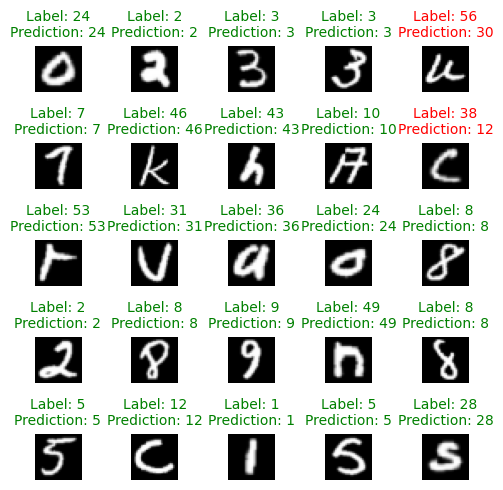

In [38]:
predctions=model.predict(X_test)
predictions=[np.argmax(i) for i in predctions]
plt.figure(figsize=(5, 5))
for i in range(25):
 plt.subplot(5, 5, i + 1)
 plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
 plt.axis('off')
 plt.title(f'Label: {y_test[i]}\nPrediction: {predictions[i]}', color='green' if y_test[i] == predictions[i] else 'red', fontsize=10) # Adjusted fontsize
plt.tight_layout() # Added to prevent overlapping titles
plt.show()

In [39]:
from sklearn.metrics import classification_report
print(classification_report(predictions,y_test))

              precision    recall  f1-score   support

           0       0.82      0.69      0.75      6819
           1       0.92      0.69      0.78      8463
           2       0.98      0.96      0.97      6004
           3       0.99      0.99      0.99      5977
           4       0.97      0.98      0.98      5570
           5       0.91      0.98      0.94      4836
           6       0.99      0.97      0.98      5830
           7       1.00      0.99      0.99      6189
           8       0.99      0.98      0.99      5641
           9       0.99      0.92      0.95      6118
          10       0.98      0.95      0.97      1099
          11       0.97      0.94      0.95       666
          12       0.98      0.77      0.86      2217
          13       0.88      0.94      0.91       730
          14       0.97      0.96      0.97       857
          15       0.94      0.79      0.86      1720
          16       0.89      0.94      0.91       423
          17       0.96    

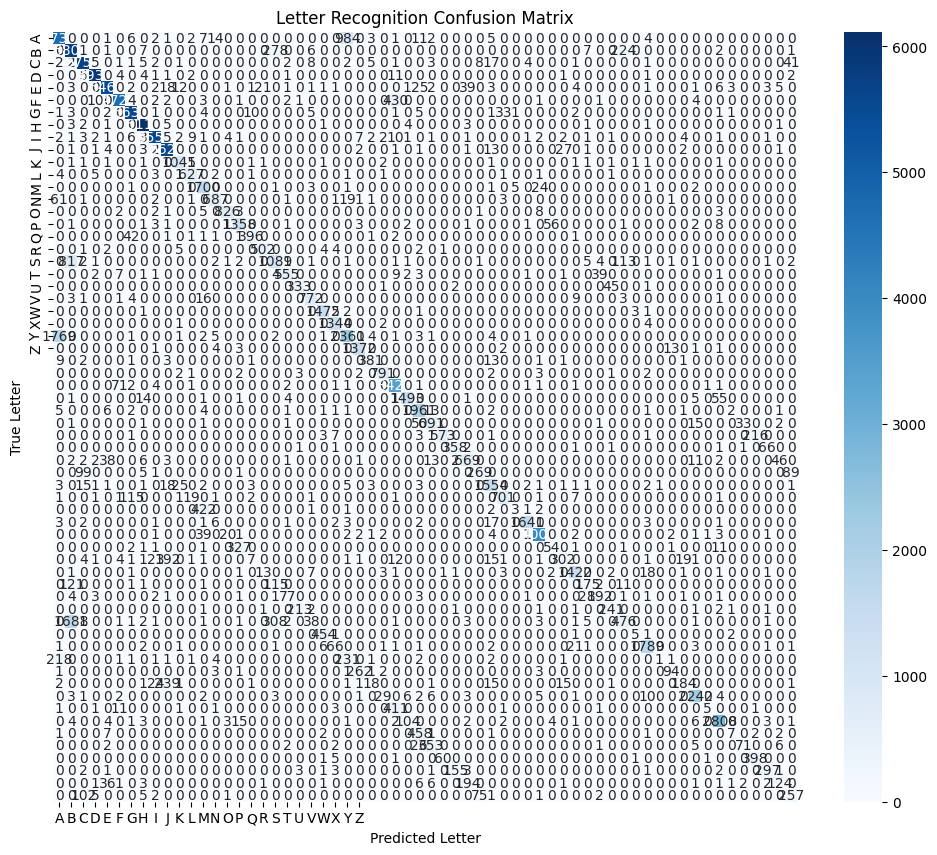

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_letters = confusion_matrix(y_test, predictions)
alphabet = [chr(65 + i) for i in range(26)]  # A-Z labels

plt.figure(figsize=(12, 10))
sns.heatmap(cm_letters, annot=True, fmt='d', cmap='Blues', 
            xticklabels=alphabet, yticklabels=alphabet)
plt.xlabel('Predicted Letter')
plt.ylabel('True Letter')
plt.title('Letter Recognition Confusion Matrix')
plt.show()